In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt


In [2]:
_path1 = 'C:\\Users\\hp\\Desktop\\3\\5.bmp'
img = cv2.imread(_path1)
print(img.shape)

(600, 600, 3)


In [3]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

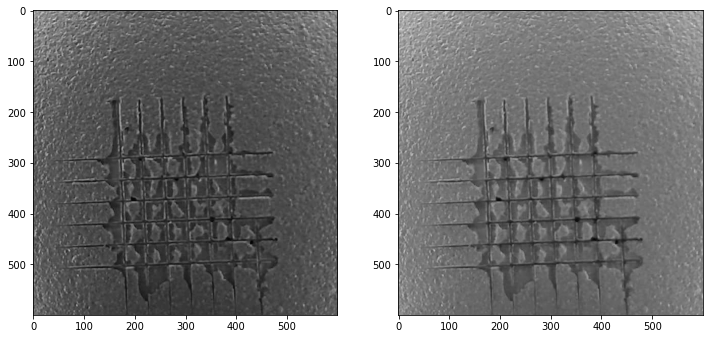

In [4]:
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(img_hsv[:,:,2], cmap='gray')

In [5]:
v_channel = img_hsv[:,:,2]

In [6]:
v_log = v_channel.astype(np.float32)/255.
# v_log = np.power(v_log, 1.8)
v_log = np.exp(v_log)

In [7]:
v_log = (v_log-v_log.min())/(v_log.max()-v_log.min())

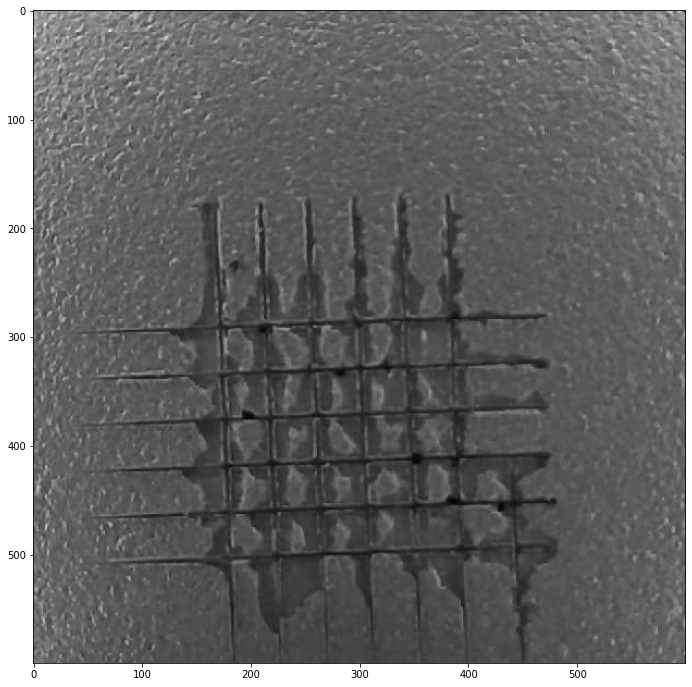

In [8]:
plt.figure(figsize=(12,12))
plt.imshow(v_log, cmap='gray')

In [9]:
hist = cv2.calcHist([v_channel], [0], None, [256], [0,256])

(array([2.0000e+00, 0.0000e+00, 0.0000e+00, 3.0000e+00, 2.0000e+00,
        4.0000e+00, 0.0000e+00, 4.0000e+00, 9.0000e+00, 6.0000e+00,
        3.0000e+00, 9.0000e+00, 1.0000e+01, 0.0000e+00, 1.3000e+01,
        2.0000e+01, 1.5000e+01, 1.7000e+01, 2.2000e+01, 1.8000e+01,
        0.0000e+00, 1.3000e+01, 1.6000e+01, 2.3000e+01, 1.7000e+01,
        2.2000e+01, 0.0000e+00, 2.3000e+01, 2.3000e+01, 2.6000e+01,
        3.5000e+01, 3.3000e+01, 3.2000e+01, 0.0000e+00, 4.0000e+01,
        6.2000e+01, 4.9000e+01, 7.5000e+01, 8.4000e+01, 1.1300e+02,
        0.0000e+00, 1.2300e+02, 1.2400e+02, 1.5700e+02, 1.6700e+02,
        1.9000e+02, 1.9500e+02, 0.0000e+00, 2.1900e+02, 2.6400e+02,
        2.6900e+02, 3.2300e+02, 2.7800e+02, 0.0000e+00, 3.8600e+02,
        4.4100e+02, 4.1800e+02, 4.5200e+02, 5.1600e+02, 5.8200e+02,
        0.0000e+00, 6.5300e+02, 7.1000e+02, 7.5400e+02, 8.7400e+02,
        9.6900e+02, 9.9600e+02, 0.0000e+00, 1.1120e+03, 1.2500e+03,
        1.2920e+03, 1.3880e+03, 1.4810e+03, 1.61

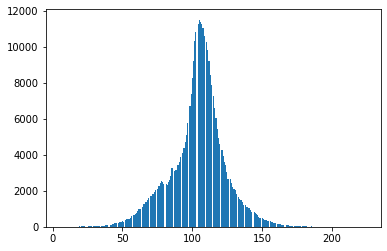

In [10]:
# plt.plot(hist)
plt.hist(v_channel.reshape(-1), bins=256)

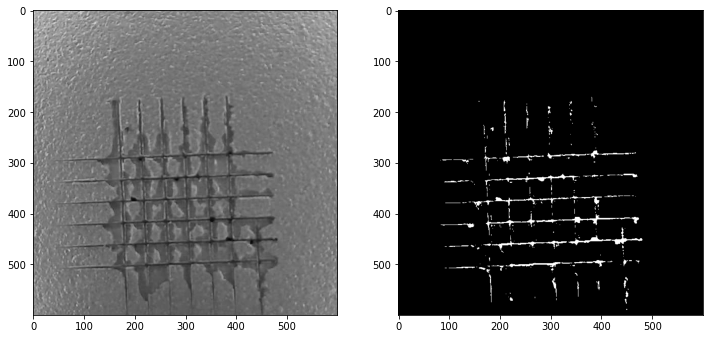

In [23]:
# ret , v_th = cv2.threshold(v_channel, 80, 255, cv2.THRESH_BINARY_INV)
ret , v_th = cv2.threshold(v_channel, 60, 255, cv2.THRESH_BINARY_INV )
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(v_th, cmap='gray')

In [12]:
v_channel_1 = v_channel.copy()
mask = np.zeros(shape=(v_channel.shape[1]+2, v_channel.shape[0]+2), dtype=np.uint8)
retval, ff_res, mask_res, rect= cv2.floodFill(v_channel_1, mask, seedPoint=(300,100), newVal=0,
                                              loDiff=20, upDiff=90, flags=4 | cv2.FLOODFILL_FIXED_RANGE)


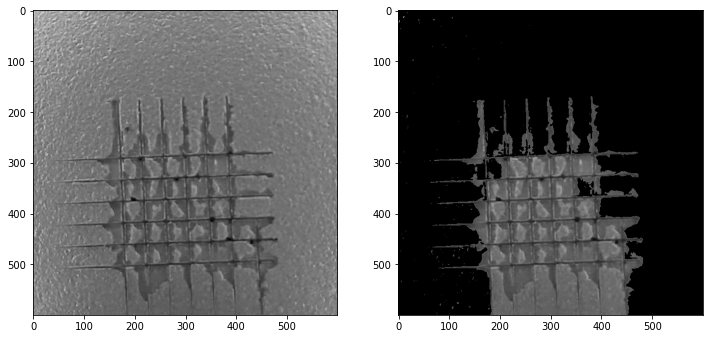

In [13]:
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(v_channel, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(v_channel_1, cmap='gray')

In [28]:
#分水岭
markers = np.zeros_like(v_channel, dtype=np.int32)
markers[v_th==0] = 1
markers[v_th==255] = 2
cv2.watershed(img, markers)

array([[-1, -1, -1, ..., -1, -1, -1],
       [-1,  1,  1, ...,  1,  1, -1],
       [-1,  1,  1, ...,  1,  1, -1],
       ...,
       [-1,  1,  1, ...,  1,  1, -1],
       [-1,  1,  1, ...,  1,  1, -1],
       [-1, -1, -1, ..., -1, -1, -1]])

In [25]:
def cc(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [30]:
print(np.count_nonzero(markers==2))

8064


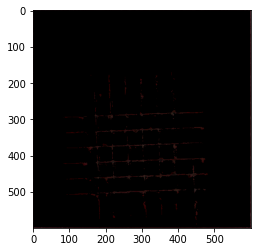

In [31]:
img_copy = img.copy()
img_copy[markers==1] = np.array([0,0,0], dtype=np.uint8)
plt.imshow(cc(img_copy))

In [32]:
dst = cv2.pyrMeanShiftFiltering(img, 2, 40 ,2)

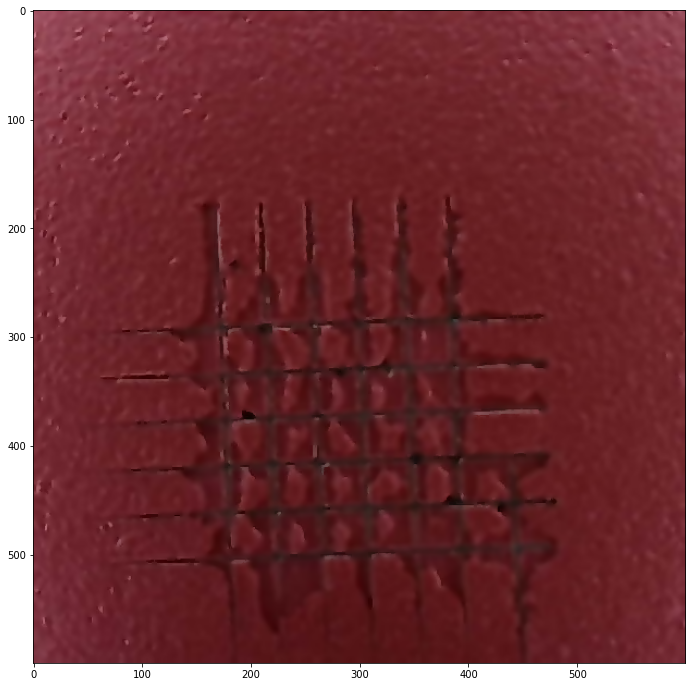

In [34]:
plt.figure(figsize=(12,12))
plt.imshow(cc(dst))

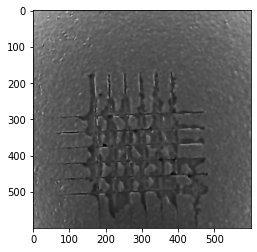

In [35]:
dst_gray = cv2.cvtColor(dst, cv2.COLOR_BGR2GRAY)
plt.imshow(dst_gray, cmap='gray')

(array([5.0000e+00, 1.7000e+01, 0.0000e+00, 1.2000e+01, 0.0000e+00,
        9.0000e+00, 2.1000e+01, 0.0000e+00, 1.2000e+01, 0.0000e+00,
        2.3000e+01, 1.3000e+01, 0.0000e+00, 3.1000e+01, 0.0000e+00,
        3.8000e+01, 6.3000e+01, 0.0000e+00, 8.1000e+01, 0.0000e+00,
        1.0800e+02, 7.9000e+01, 0.0000e+00, 1.0600e+02, 0.0000e+00,
        1.2500e+02, 1.5000e+02, 0.0000e+00, 1.8500e+02, 0.0000e+00,
        2.9800e+02, 0.0000e+00, 2.8000e+02, 4.0200e+02, 0.0000e+00,
        5.4400e+02, 0.0000e+00, 6.5100e+02, 7.8300e+02, 0.0000e+00,
        9.7000e+02, 0.0000e+00, 1.2830e+03, 1.6520e+03, 0.0000e+00,
        2.1520e+03, 0.0000e+00, 2.8050e+03, 3.3860e+03, 0.0000e+00,
        3.7560e+03, 0.0000e+00, 4.4080e+03, 5.2110e+03, 0.0000e+00,
        6.3660e+03, 0.0000e+00, 6.4610e+03, 6.6540e+03, 0.0000e+00,
        6.3830e+03, 0.0000e+00, 6.4360e+03, 0.0000e+00, 6.2160e+03,
        6.2710e+03, 0.0000e+00, 6.5900e+03, 0.0000e+00, 7.2300e+03,
        7.8920e+03, 0.0000e+00, 9.5240e+03, 0.00

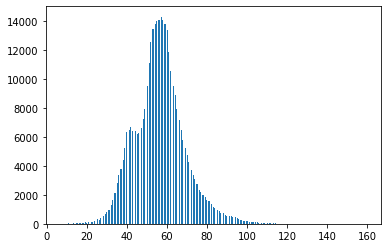

In [40]:
plt.hist(dst_gray.reshape(-1), bins=256)

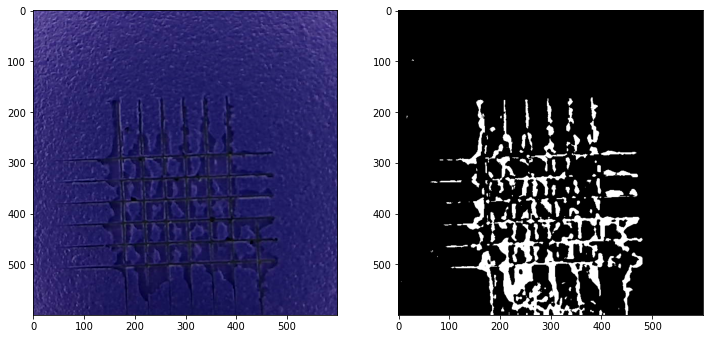

In [39]:
ret , v_th = cv2.threshold(dst_gray, 40, 255, cv2.THRESH_BINARY_INV )
plt.figure(figsize=(12,24))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(v_th, cmap='gray')